# House Price Prediction Using Machine Learning Regression Models

# Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Load Dataset

In [7]:

df = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Display First 5 Rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [9]:
df.shape

(2000, 10)

In [10]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

# Exploratory Data Analysis (EDA)

In [11]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


# Data Cleaning

## Check Missing Values

In [12]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [13]:

# Remove Missing Values

df.dropna(inplace=True)

# Verify Missing Values Again
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


# Data Visualization

## 1. House Price Distribution

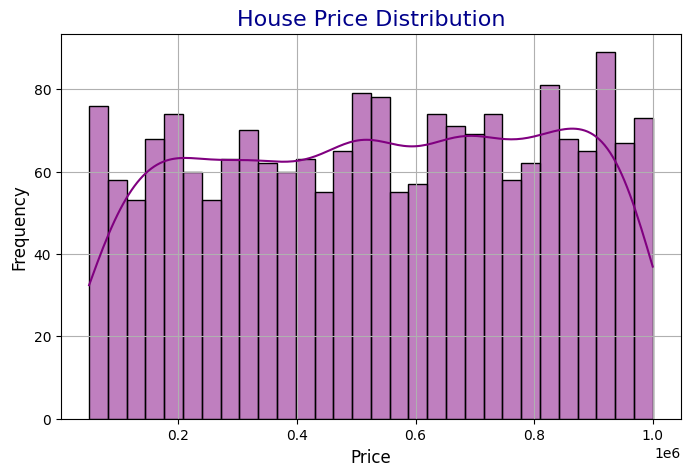

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("House Price Distribution",
          fontsize=16,
          color='darkblue')

plt.xlabel("Price",
           fontsize=12)

plt.ylabel("Frequency",
           fontsize=12)

plt.grid(True)

plt.show()

## 2. Correlation Heatmap

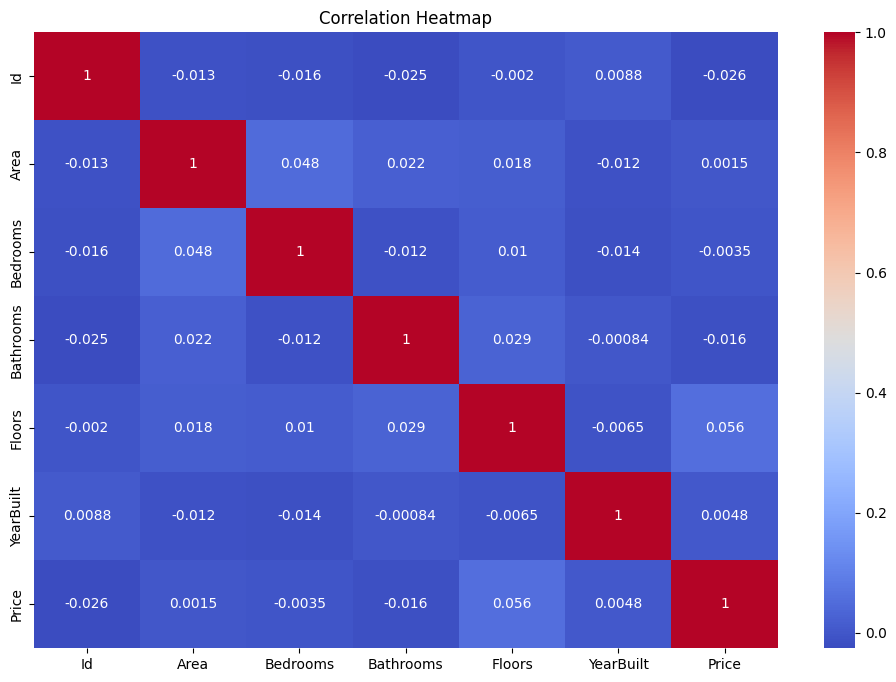

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## 3. Scatter Plot

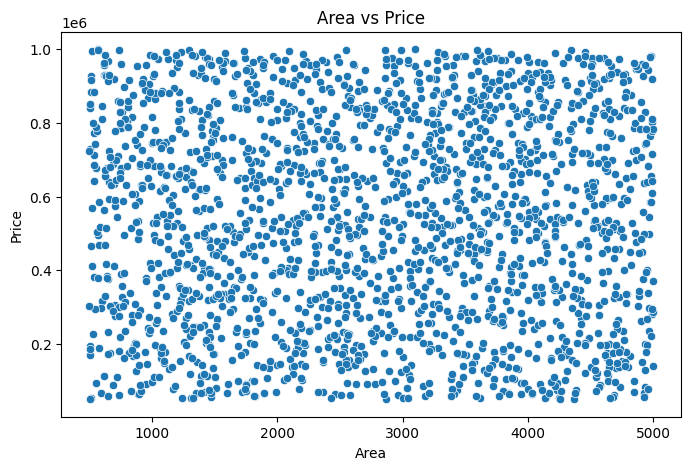

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Area'],
    y=df['Price']
)

plt.title("Area vs Price")

plt.show()

## 4. Box Plot

/tmp/ipykernel_4433/3949068197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


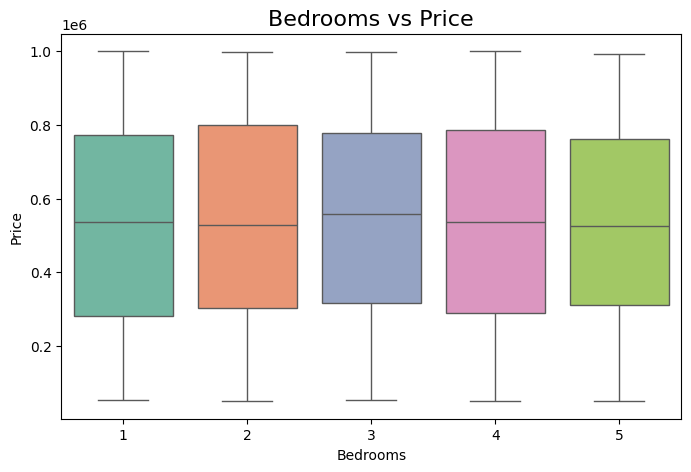

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Bedrooms'],
    y=df['Price'],
    palette='Set2'
)

plt.title("Bedrooms vs Price",
          fontsize=16)

plt.show()

## 5. Pair Plot

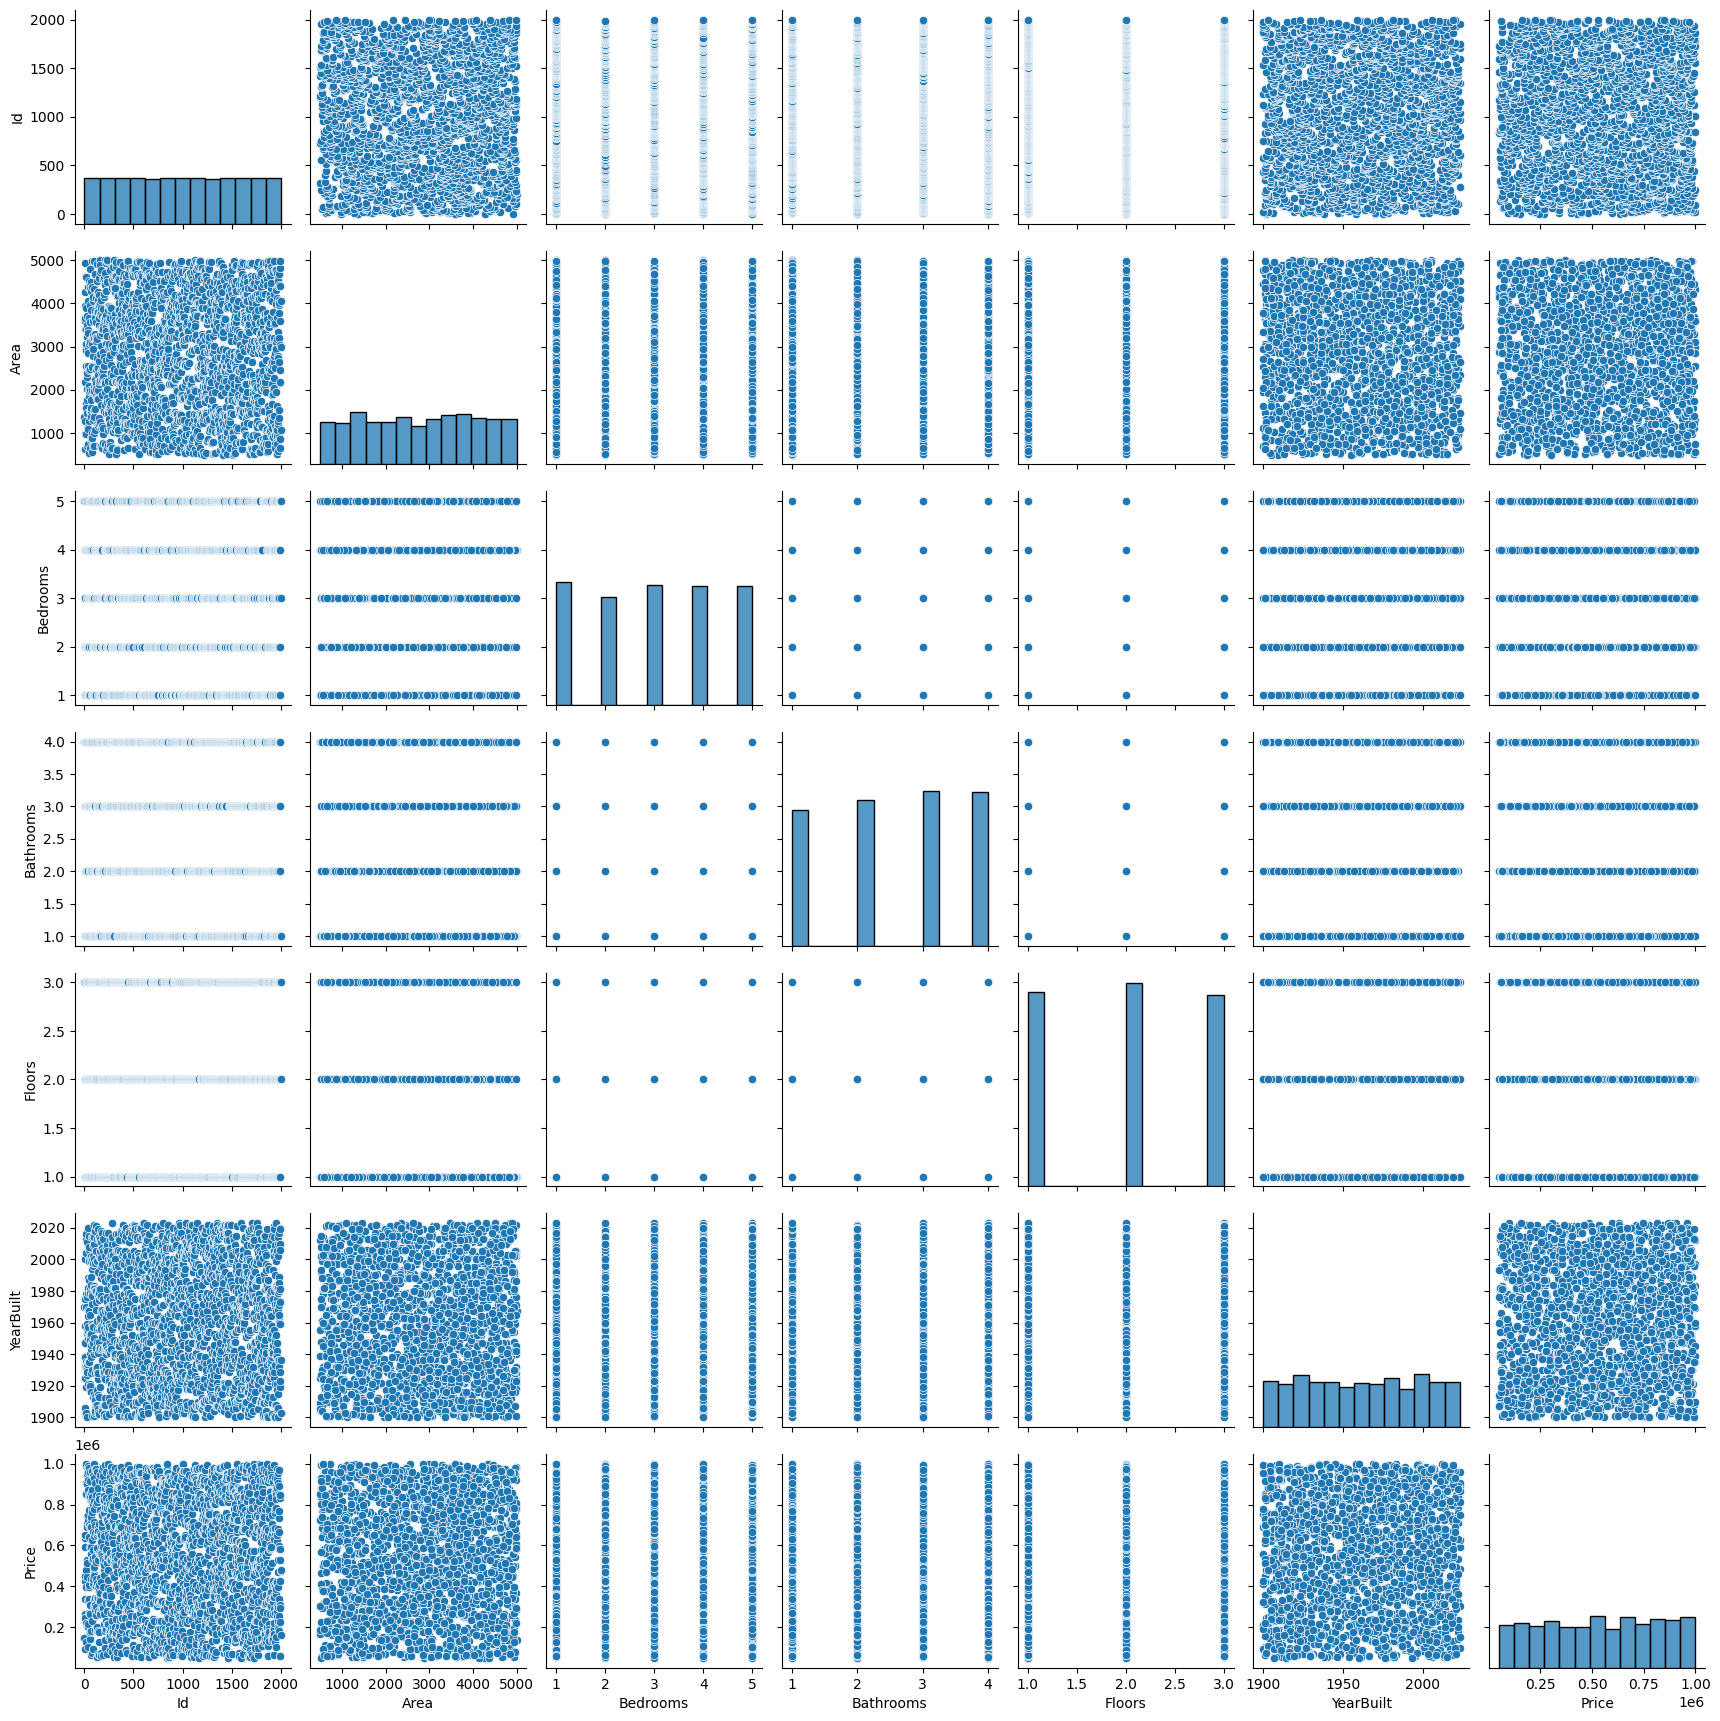

In [18]:
sns.pairplot(df)

plt.show()

# Feature Engineering

In [19]:
df['HouseAge'] = 2025 - df['YearBuilt']

df['TotalRooms'] = df['Bedrooms'] + df['Bathrooms']

# Data Preprocessing

In [20]:
# Convert categorical columns into numerical

df = pd.get_dummies(df, drop_first=True)

# Feature Selection

In [21]:
X = df.drop(['Id', 'Price'], axis=1)

y = df['Price']

# Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model

In [23]:
lr_model = LinearRegression()

# Train Model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

## Linear Regression Evaluation

In [24]:
print("Linear Regression Results")
print()

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("MSE:",
      mean_squared_error(y_test, lr_pred))

print("R2 Score:",
      r2_score(y_test, lr_pred))

Linear Regression Results

MAE: 243241.97758826384
MSE: 78321466146.03279
R2 Score: -0.006717808430749539


# Decision Tree Regressor

In [25]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

In [26]:
# Train Model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

## Decision Tree Evaluation

In [27]:
print("Decision Tree Results")
print()

print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("MSE:",
      mean_squared_error(y_test, dt_pred))

print("R2 Score:",
      r2_score(y_test, dt_pred))

Decision Tree Results

MAE: 252457.07314689606
MSE: 86235920475.05826
R2 Score: -0.10844754497814635


# Random Forest Regressor

In [28]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Random Forest Evaluation

In [29]:
print("Random Forest Results")
print()

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("R2 Score:",
      r2_score(y_test, rf_pred))

Random Forest Results

MAE: 252556.8761939547
MSE: 85532989682.41176
R2 Score: -0.0994123087667591


# XGBoost Regressor

In [30]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

## XGBoost Evaluation

In [31]:
print("XGBoost Results")
print()

print("MAE:",
      mean_absolute_error(y_test, xgb_pred))

print("MSE:",
      mean_squared_error(y_test, xgb_pred))

print("R2 Score:",
      r2_score(y_test, xgb_pred))

XGBoost Results

MAE: 259172.15625
MSE: 91497005056.0
R2 Score: -0.17607176303863525


# Model Comparison

In [32]:
models = [
    'Linear Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

r2_scores = [

    r2_score(y_test, lr_pred),

    r2_score(y_test, dt_pred),

    r2_score(y_test, rf_pred),

    r2_score(y_test, xgb_pred)
]

comparison_df = pd.DataFrame({

    'Model': models,

    'R2 Score': r2_scores
})

print(comparison_df)

               Model  R2 Score
0  Linear Regression -0.006718
1      Decision Tree -0.108448
2      Random Forest -0.099412
3            XGBoost -0.176072


# Model Comparison using R2 Score

/tmp/ipykernel_4433/3817695876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


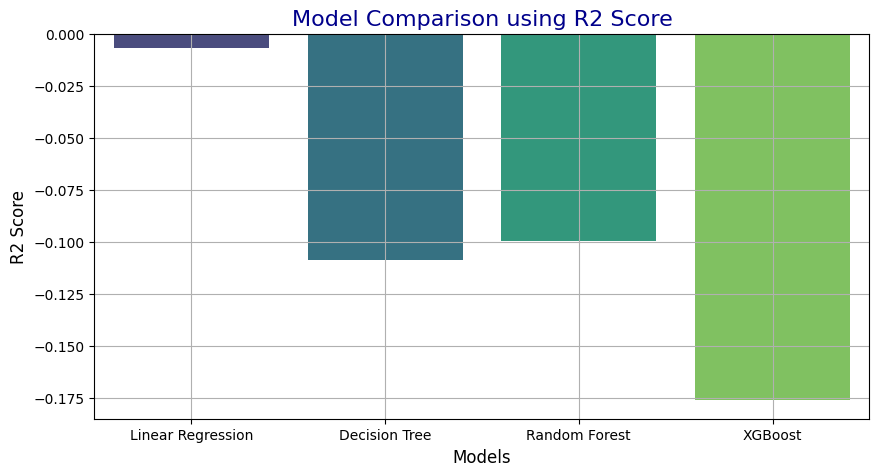

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison_df,
    palette='viridis'
)

plt.title(
    "Model Comparison using R2 Score",
    fontsize=16,
    color='darkblue'
)

plt.xlabel(
    "Models",
    fontsize=12
)

plt.ylabel(
    "R2 Score",
    fontsize=12
)

plt.grid(True)

plt.show()